In [1]:
# get packages
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision

In [2]:
# set the device
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Training with device = {device}")

Training with device = mps


In [3]:
# get cifar-10 dataset
data = "./data"

# define transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

])

# get datasets
train_dataset = torchvision.datasets.CIFAR10(
    root = data,
    train = True,
    download = True,
    transform = train_transform
)

val_dataset = torchvision.datasets.CIFAR10(
    root = data,
    train = False,
    download = True,
    transform = val_transform
)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


In [4]:
# define the objective function for Optuna
from models.flexiblecnn import FlexibleCNN
from utilities.train_model import train_model

def objective(trial, device) :
    """
    The objective trial for auto hyperparameterization using Optuna

    For each trial, the function samples a set of hyperparams, constructs a model, trains for a fixed number
    of epochs, evaluates against the validatin set, and returns the accuracy. Optuna uses the returned
    accuracy to guide its search for the best hyperparams.
    """

    # set the hyperparameter ranges using the trial.suggest_ method
    num_layers = trial.suggest_int("num_layers", 1, 3)
    num_filters = [trial.suggest_int(f"num_filters_{i}", 16, 128) for i in range(num_layers)]
    kernel_sizes = [trial.suggest_categorical(f"kernel_size{i}", [3,5]) for i in range(num_layers)]
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    fc_size = trial.suggest_int("fc_size", 64, 256)

    # the model needs to be instantiated with a dummy variable to initialize the classifier
    model = FlexibleCNN(num_layers, num_filters, kernel_sizes, dropout_rate, fc_size)
    model = model.to(device)
    dummy = torch.randn(1, 3, 32, 32).to(device)
    model(dummy)

    # optimizer
    learning_rate = 0.001
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = learning_rate)


    # data loaders
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
    val_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

    # train
    num_epochs = 10
    accuracy = train_model(model, train_loader, val_loader, loss_func, optimizer, device, num_epochs)
    return accuracy

In [5]:
# define the study, using a lambda function to pass in the device
# we are trying to maximize our objective function
study = optuna.create_study(direction = 'maximize')
n_trials = 20
study.optimize(lambda trial: objective(trial, device), n_trials = n_trials)

[I 2026-04-14 21:16:38,118] A new study created in memory with name: no-name-09566537-4783-4811-8d21-363cf924f97a
Epoch 5/5: 100%|██████████| 391/391 [00:19<00:00, 19.57it/s, loss=1]    
[I 2026-04-14 21:18:36,047] Trial 0 finished with value: 0.7579600214958191 and parameters: {'num_layers': 2, 'num_filters_0': 60, 'num_filters_1': 55, 'kernel_size0': 5, 'kernel_size1': 3, 'dropout_rate': 0.37612881635307904, 'fc_size': 146}. Best is trial 0 with value: 0.7579600214958191.
Epoch 5/5: 100%|██████████| 391/391 [00:21<00:00, 18.38it/s, loss=1.22] 
[I 2026-04-14 21:20:38,435] Trial 1 finished with value: 0.6819800138473511 and parameters: {'num_layers': 1, 'num_filters_0': 91, 'kernel_size0': 3, 'dropout_rate': 0.40868229713919824, 'fc_size': 193}. Best is trial 0 with value: 0.7579600214958191.
Epoch 5/5: 100%|██████████| 391/391 [00:18<00:00, 21.63it/s, loss=0.951]
[I 2026-04-14 21:22:23,859] Trial 2 finished with value: 0.7213199734687805 and parameters: {'num_layers': 1, 'num_filters_

In [6]:
# analyze results
df = study.trials_dataframe()
df

,number,value,datetime_start,datetime_complete,duration,params_dropout_rate,params_fc_size,params_kernel_size0,params_kernel_size1,params_kernel_size2,params_num_filters_0,params_num_filters_1,params_num_filters_2,params_num_layers,state
0,0,0.75796,2026-04-14 21:16:38.119565,2026-04-14 21:18:36.047386,0 days 00:01:57.927821,0.376129,146,5,3.0,NaN,60,55.0,NaN,2,COMPLETE
1,1,0.68198,2026-04-14 21:18:36.049035,2026-04-14 21:20:38.435001,0 days 00:02:02.385966,0.408682,193,3,NaN,NaN,91,NaN,NaN,1,COMPLETE
2,2,0.72132,2026-04-14 21:20:38.436541,2026-04-14 21:22:23.859045,0 days 00:01:45.422504,0.139482,71,3,NaN,NaN,43,NaN,NaN,1,COMPLETE
3,3,0.74992,2026-04-14 21:22:23.860948,2026-04-14 21:24:22.685216,0 days 00:01:58.824268,0.485483,169,5,3.0,NaN,41,107.0,NaN,2,COMPLETE
4,4,0.79006,2026-04-14 21:24:22.687478,2026-04-14 21:27:00.825875,0 days 00:02:38.138397,0.290736,143,3,5.0,3.0,61,111.0,127.0,3,COMPLETE
5,5,0.72488,2026-04-14 21:27:00.827536,2026-04-14 21:28:56.568433,0 days 00:01:55.740897,0.249647,132,5,NaN,NaN,58,NaN,NaN,1,COMPLETE
6,6,0.75924,2026-04-14 21:28:56.570005,2026-04-14 21:30:51.399468,0 days 00:01:54.829463,0.220137,203,5,NaN,NaN,41,NaN,NaN,1,COMPLETE
7,7,0.69284,2026-04-14 21:30:51.401231,2026-04-14 21:32:24.894864,0 days 00:01:33.493633,0.285848,110,3,NaN,NaN,19,NaN,NaN,1,COMPLETE
8,8,0.71876,2026-04-14 21:32:24.896927,2026-04-14 21:35:09.696324,0 days 00:02:44.799397,0.445452,121,5,3.0,3.0,110,124.0,126.0,3,COMPLETE
9,9,0.70192,2026-04-14 21:35:09.698227,2026-04-14 21:37:03.933474,0 days 00:01:54.235247,0.278067,65,5,NaN,NaN,46,NaN,NaN,1,COMPLETE


In [7]:
best_trial = study.best_trial
print("----------------")
print("---Best Trial---")
print(f"Accuracy = {best_trial.value}")
print("----------------")
print("Hypermeters:")
print(best_trial.params)

----------------
---Best Trial---
Accuracy = 0.8158000111579895
----------------
Hypermeters:
{'num_layers': 3, 'num_filters_0': 78, 'num_filters_1': 41, 'num_filters_2': 122, 'kernel_size0': 3, 'kernel_size1': 5, 'kernel_size2': 5, 'dropout_rate': 0.11074001132081543, 'fc_size': 183}


/var/folders/bm/hpym5ltd6531p4dhr0hp3kjr0000gn/T/ipykernel_30939/378691724.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


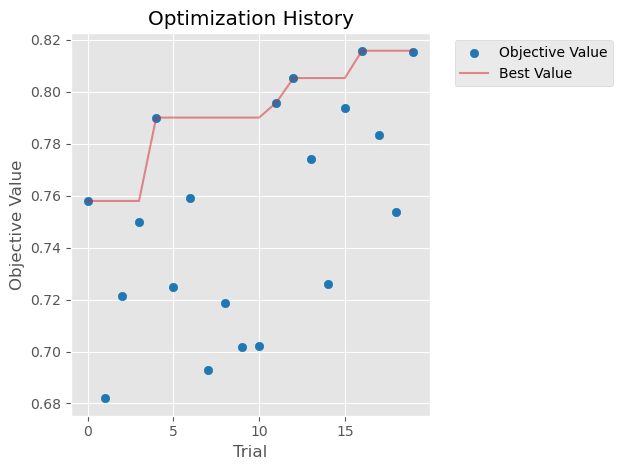

In [ ]:
# visualize results
import matplotlib.pyplot as plt

# optimization
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optimization History")
plt.show()

/var/folders/bm/hpym5ltd6531p4dhr0hp3kjr0000gn/T/ipykernel_30939/3333402817.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

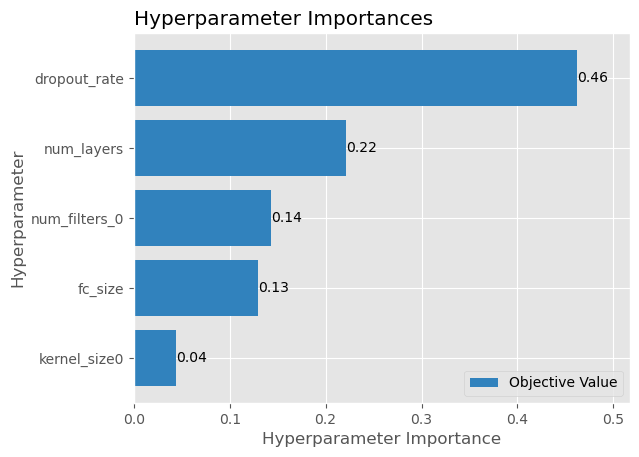

In [16]:
# visualize results

# hyperparameter importance
optuna.visualization.matplotlib.plot_param_importances(study)


/var/folders/bm/hpym5ltd6531p4dhr0hp3kjr0000gn/T/ipykernel_30939/2667805393.py:3: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_parallel_coordinate(


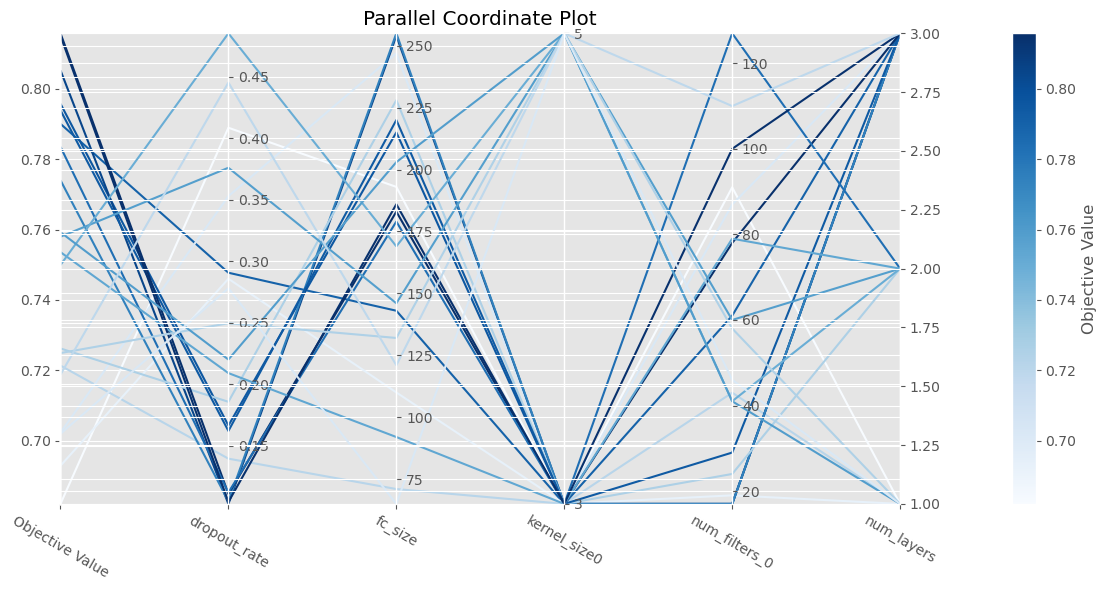

In [27]:
# visualize results

ax = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study, params = ['num_layers', 'num_filters_0', 'kernel_size0', 'dropout_rate', 'fc_size']
)
fig = ax.figure
fig.set_size_inches(12, 6, forward = True)
fig.tight_layout()